**Faça uma análise do dataset utilizando dendograma. Verifique as possibilidades de clusterização e aplique o k-medias. Observe os resultados e descreva sua iterpretação no relatório. Dica: Observe se há necessidade de normalização dos dados nas colunas ou nas linhas.**

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


     labels  y
0         1  0
1         1  0
2         1  0
3         1  0
4         0  0
..      ... ..
564       1  0
565       1  0
566       0  0
567       1  0
568       0  1

[569 rows x 2 columns]


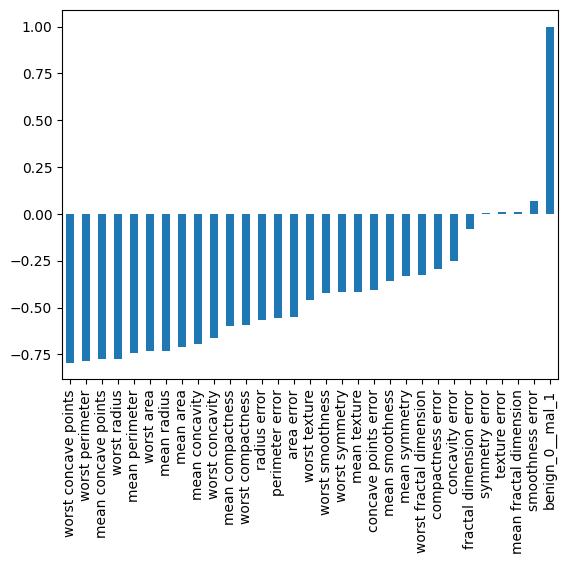

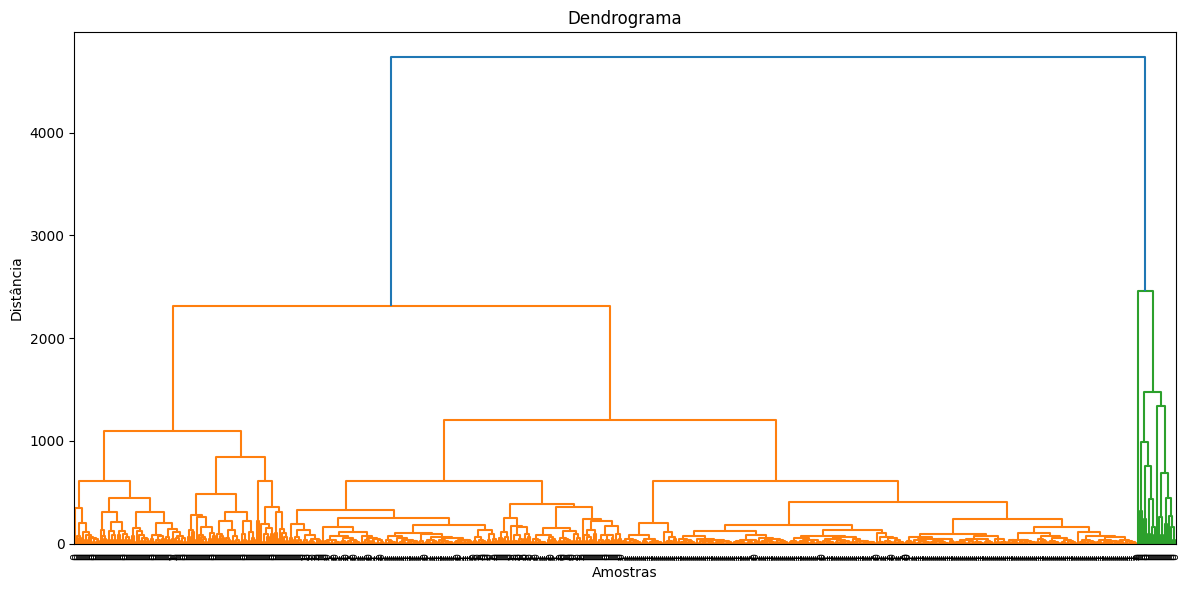

[17 19 14 32 11 24  2 22 24 24 25  7  4 27 24 28 29  7 41 24 32 31 29 42
 18  5 27  6  7  8 16 22  5 15  7  8 23 32 23 24 24 33 16 22 24  2 31 24
 32 24 33 24 32  9 29 33 20 28 32 31 34 31 28 31 22 28 31 33 31 32 15 31
  1 22 32  7 32  2 11 32 33 32 39  4 32  2 23  2 32 23 23 27 22 24 29 14
 33 34 33 23 22 31 32 34 34 22 33 32 44 33 34 32 23 34 31 32 31 29  7  9
 33  2 43 23 32 24 22 10 23 11 32 25 25 27  2 32 32 33 28 34 34  7 33 32
 34 33 32 23 23 24 32 31 34 34 24 32  9 26 32 33 32 10 20 32 45 23 34  8
  1 23 32 28 29 34 34 31 34 26 32 32 37 19  7 33 29 34  6 33 33 32 23 32
 31 24 23 32 22  9 16 28 32  8 43 30 24 29 34  8 32 27 11 32 46 26 22 24
 32 34 21 41 24 24 34 29 24 27 34 23 32 24  8 34 33 13 34 24 40 14 23  5
 24 32 33 24 10 34 32 32 34 33 19 33 21  8 21 22 21 27  7 29 13  8  9 29
  5 35 34 24 32 34 24 34 44 34  9 33 33  4 24 24 16 32 11 26 32 32 32 32
 34 33 23 23 32 32 32 24 34 32 23 34 21 32 14 34 33 33 32 31 24 24 33 27
 32 33 31 32 32  6 31 32 34 11 32 21 32 32 23 32 25

In [ ]:
#@title Texto de título padrão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from scipy.cluster.hierarchy import fcluster
import seaborn as sns


# Carregando o dataset e análise (pré-processamento)
dataset = pd.read_csv('/content/cancer_classification.csv')
print(dataset.describe())
dataset.describe()
dataset.info()
dataset.head()
dataset.isnull().sum()

# Primeiro vamos fazer a normalização
#mostrar a correlação entra a coluna principal e as demais colunas do dataset
dataset.corr()['benign_0__mal_1'].sort_values().plot(kind='bar')
X = dataset.drop(['benign_0__mal_1'], axis=1)
y = dataset['benign_0__mal_1'].values


normalizer = Normalizer()
kmeans = KMeans(n_clusters=2)
pipeline = make_pipeline(normalizer, kmeans)
pipeline.fit(X)
labels = pipeline.predict(X)
df = pd.DataFrame({'labels': labels, 'y': y})
print(df)

# Após a normalização, faremos o dendrograma
mergings = linkage(X, method='complete')
plt.figure(figsize=(12, 6))
dendrogram(mergings,
           labels=y,
           leaf_rotation=90,
           leaf_font_size=8)
plt.xlabel('Amostras')
plt.ylabel('Distância')
plt.title('Dendrograma')
plt.tight_layout()
plt.show()

#agora faremos o processo de clusterização

mergings = linkage(X, method='complete')
labels = fcluster(mergings, 200, criterion = 'distance')
print(labels)




       mean radius  mean texture  mean perimeter    mean area  \
count    60.000000     60.000000       60.000000    60.000000   
mean     13.570300     19.130167       88.129833   589.363333   
std       2.799051      4.024639       19.406954   253.649082   
min       8.597000     12.350000       54.090000   221.200000   
25%      11.505000     15.687500       73.900000   403.325000   
50%      13.115000     19.040000       85.275000   529.450000   
75%      15.010000     21.547500       97.770000   685.725000   
max      20.600000     29.330000      140.100000  1265.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count        60.000000         60.000000       60.000000            60.000000   
mean          0.097133          0.101603        0.072056             0.042268   
std           0.011794          0.049616        0.067156             0.031839   
min           0.073720          0.035150        0.000000             0.000000   
25%      

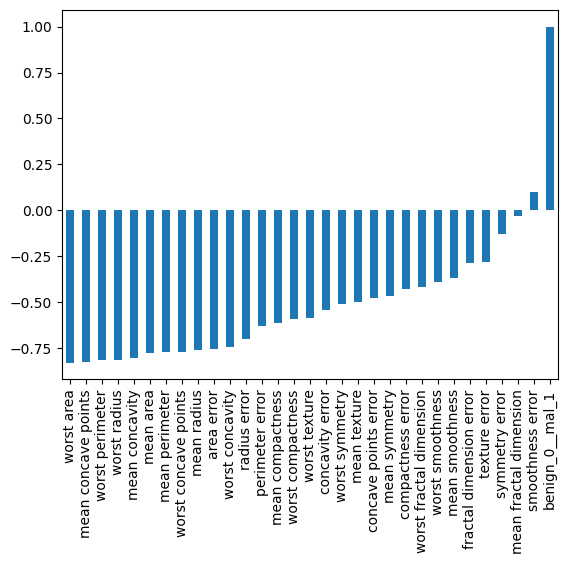

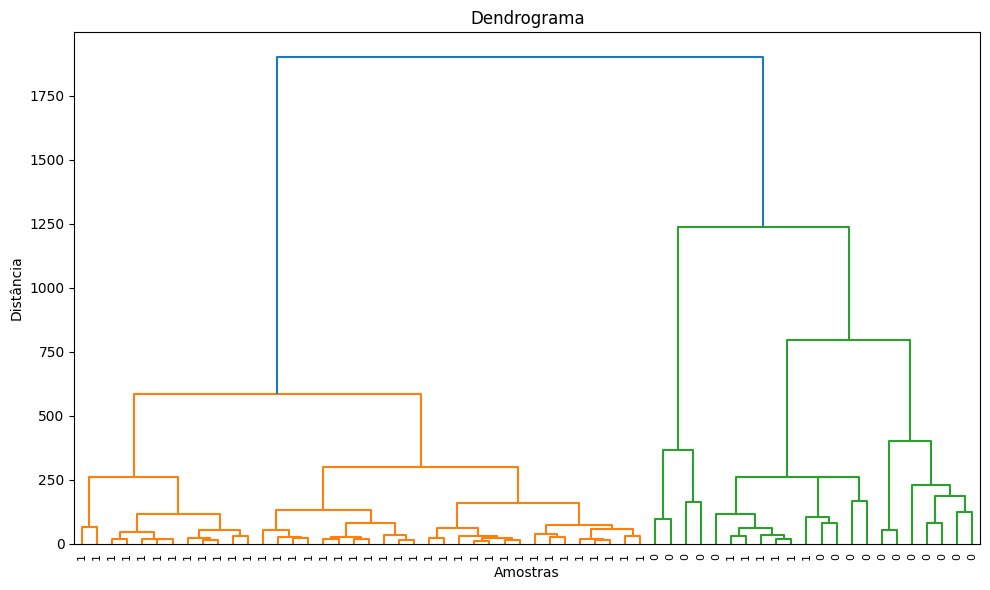

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [ ]:
#@title Texto de título padrão
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from scipy.cluster.hierarchy import fcluster
import seaborn as sns
from sklearn.model_selection import train_test_split

# Carregando o dataset e análise (pré-processamento)
dataset = pd.read_csv('/content/cancer_classification.csv')
dataset = dataset.sample(n = 60, replace = False)
print(dataset.describe())
dataset.describe()
dataset.info()
dataset.head()
dataset.isnull().sum()

# Primeiro vamos fazer a normalização
#mostrar a correlação entra a coluna principal e as demais colunas do dataset
dataset.corr()['benign_0__mal_1'].sort_values().plot(kind='bar')
X = dataset.drop(['benign_0__mal_1'], axis=1)
y = dataset['benign_0__mal_1'].values



normalizer = Normalizer()
n = normalizer.fit_transform(X)
df = pd.DataFrame(n, columns=X.columns)
df['benign_0__mal_1'] = y
print(df)

# Após a normalização, faremos o dendrograma
mergings = linkage(X, method='complete')
plt.figure(figsize=(10, 6))
dendrogram(mergings,
           labels=y,
           leaf_rotation=90,
           leaf_font_size=8)
plt.xlabel('Amostras')
plt.ylabel('Distância')
plt.title('Dendrograma')
plt.tight_layout()
plt.show()

#agora faremos o processo de clusterização

mergings = linkage(X, method='complete')
labels = fcluster(mergings, 2000, criterion = 'distance')
print(labels)
plt.show()

<Axes: xlabel='benign_0__mal_1', ylabel='count'>

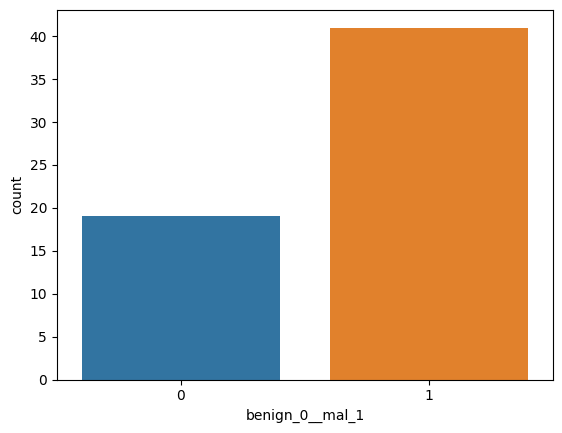

In [ ]:
#@title Texto de título padrão
# já identificamos a coluna principal, agora vou ver  as diferentes categorias dentro dela
sns.countplot(data=df, x='benign_0__mal_1')

 **Reduza o dataset T-SNE e com PCA para duas dimensões. Plote o gráfico do atributos que as duas técnicas geraram. De forma subjetiva e visual, qual dos gráficos você avredita que vai possuir um melhor desempenho em um processo de classificação utilizando os dois atribuitos ?**

Text(0.5, 1.0, 'PCA')

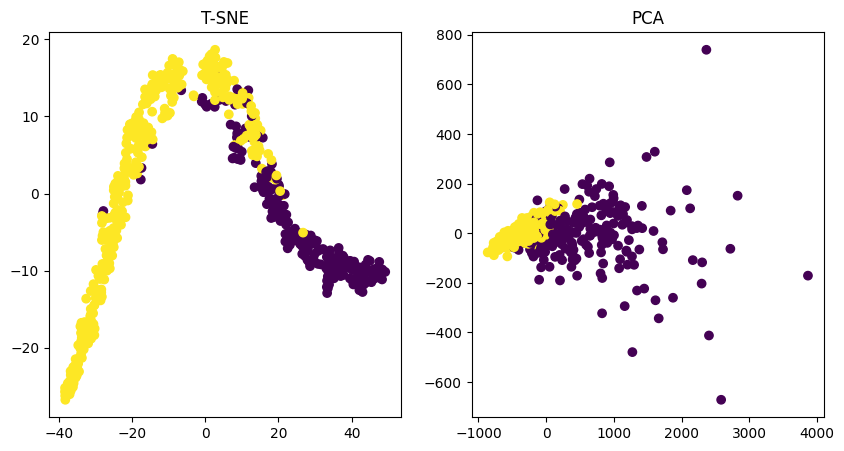

In [ ]:
#@title Texto de título padrão
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from scipy.stats import pearsonr



dataset = pd.read_csv('/content/cancer_classification.csv')
X = dataset.drop(['benign_0__mal_1'], axis=1)
y = dataset['benign_0__mal_1'].values
#z = normalized_dataset = normalize(X)


#tsne_features = model.fit_transform(X)

#xs = tsne_features[:, 0]
#ys = tsne_features[:, 1]

#plt.scatter(xs, ys, alpha = 0.5)

#for x, y, benign_0__mal_1 in zip(xs, ys, y):
 #   plt.annotate(benign_0__mal_1, (x, y), fontsize=5, alpha=0.75)
#plt.show()

model = TSNE(n_components=2, random_state=42)
X_tsne = model.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
plt.title('T-SNE')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title('PCA')

**Utilizando os dados da questão 2, aplique algum método de classificação e gere números que quantificam o desempenho deste. Compare os números classificando o dataset reduzido pelo PCA e pelo T-SNE.**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_pca_train, X_pca_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
X_tsne_train, X_tsne_test, y_train, y_test = train_test_split(X_tsne, y, test_size=0.2, random_state=42)

# Classificação com os dados reduzidos pelo PCA
classifier_pca = LogisticRegression()
classifier_pca.fit(X_pca_train, y_train)
y_pred_pca = classifier_pca.predict(X_pca_test)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

# Classificação com os dados reduzidos pelo T-SNE
classifier_tsne = LogisticRegression()
classifier_tsne.fit(X_tsne_train, y_train)
y_pred_tsne = classifier_tsne.predict(X_tsne_test)
accuracy_tsne = accuracy_score(y_test, y_pred_tsne)

print("Acurácia com dados reduzidos pelo PCA:", accuracy_pca)
print("Acurácia com dados reduzidos pelo T-SNE:", accuracy_tsne)


Acurácia com dados reduzidos pelo PCA: 0.9649122807017544
Acurácia com dados reduzidos pelo T-SNE: 0.9298245614035088


**Utilizando análise de variância do PCA. Reduza a dimensão para realizar uma classificação utilizando somente as colunas de maior variância. Aplique o mesmo método de classificação testado na questão 3. Gere os mesmos números que analisam o desempenho do classificador e verifique se houve melhoria no resultado.**

In [ ]:
#@title Texto de título padrão
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

dataset = pd.read_csv('/content/cancer_classification.csv')
X = dataset.drop(['benign_0__mal_1', 'smoothness error'], axis=1)
y = dataset['benign_0__mal_1']

variances = X.var()
sorted_columns = variances.sort_values(ascending=False).index

num_columns_to_keep = 2

X_reduced = X[sorted_columns[:num_columns_to_keep]]

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)


classifier = LogisticRegression()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)


print("Acurácia antes da redução de dimensionalidade:", accuracy_pca)
print("Acurácia após a redução de dimensionalidade:", accuracy)



Acurácia antes da redução de dimensionalidade: 0.9649122807017544
Acurácia após a redução de dimensionalidade: 0.9649122807017544


**Você descobriu qual a melhor forma de pré-processar os dados. Assim, utilizando a metodologia que proporcionou o melhor acerto do classficador faça agora uma comparação entre classicadores para que você também possa descobrir qual classificador mais adequado. Utilize outra técnica de classificação com os mesmo dados, gere os numeros que quantificam o desempenho e faça uma comparação entre estes. Conclua o relatótório com auxílio de um fluxogragrama mostrando qual a metodologia completa para classificação dos dados do seu dataset.**

In [ ]:
#@title Texto de título padrão
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

dataset = pd.read_csv('/content/cancer_classification.csv')
X = dataset.drop(['benign_0__mal_1'], axis=1)
y = dataset['benign_0__mal_1']

variances = X.var()
sorted_columns = variances.sort_values(ascending=False).index

num_columns_to_keep = 2

X_reduced = X[sorted_columns[:num_columns_to_keep]]

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

classifier = KNeighborsClassifier()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)


print("Acurácia antes da redução de dimensionalidade:", accuracy_pca)
print("Acurácia após a redução de dimensionalidade:", accuracy)

Acurácia antes da redução de dimensionalidade: 0.9649122807017544
Acurácia após a redução de dimensionalidade: 0.9473684210526315
